In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import timedelta
import math

pd.set_option('display.max_columns',None)

In [2]:
def get_dataset(dataset:str)->str:
    try:
        return pd.read_csv(os.path.join('..','..','data','processed',f'{dataset}.csv'))
    except Exception as e:
        warnings.warn(f'"{dataset}" dataset not present.')
        return None

In [3]:
data = get_dataset('cleaned_trained_data')

In [4]:
# Convert columns to their appropriate datatypes.

date_col = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date',
            'order_delivered_customer_date','order_estimated_delivery_date','shipping_limit_date']

number_col = ['payment_sequential','payment_installments','order_item_id','seller_zip_code_prefix']

for col in date_col:
    data[col] = pd.to_datetime( data[col])
    

for col in number_col:
    data[col] = data[col].astype('Int64')



In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 81048 entries, 0 to 81047
Data columns (total 39 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       81048 non-null  str           
 1   customer_id                    81048 non-null  str           
 2   order_status                   81048 non-null  str           
 3   order_purchase_timestamp       81048 non-null  datetime64[us]
 4   order_approved_at              81048 non-null  datetime64[us]
 5   order_delivered_carrier_date   81048 non-null  datetime64[us]
 6   order_delivered_customer_date  81048 non-null  datetime64[us]
 7   order_estimated_delivery_date  81048 non-null  datetime64[us]
 8   payment_sequential             81048 non-null  Int64         
 9   payment_type                   81048 non-null  str           
 10  payment_installments           81048 non-null  Int64         
 11  payment_value             

In [6]:
data['product_volume_cm3'] = data['product_length_cm'] * data['product_height_cm'] * data['product_width_cm']

In [7]:
data.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_latitude,customer_longitude,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,seller_latitude,seller_longitude,delivery_distance_km,product_volume_cm3
0,18668c1a8328478efec728fc614c3b55,6d547f62fd060718fd2a268a4fa2a1fa,delivered,2017-05-04 15:06:03,2017-05-04 15:22:30,2017-05-05 12:00:40,2017-05-23 11:12:49,2017-05-25,1,credit_card,8,162.10,288bca9dae3585557dfd5dfdf7289600,9371,maua,SP,-23.669305,-46.477297,1,4fcb3d9a5f4871e8362dfedbdb02b064,8581055ce74af1daba164fdbd55a40de,2017-05-10 15:22:30,143.80,18.30,automotivo,53.0,603.0,1.0,5950.0,65.0,11.0,65.0,auto,7112,guarulhos,SP,-23.468737,-46.513845,23.0,46475.0
1,e35bd284b205ea082108ae3703c84428,ac8e62b68c0a8fd4d4eb818903300c68,delivered,2017-11-10 13:42:22,2017-11-13 07:50:30,2017-11-14 16:09:51,2017-11-22 14:12:32,2017-12-05,1,credit_card,4,354.16,9b85684cedccb35b49cbad4fcfe04417,4119,sao paulo,SP,-23.592552,-46.634911,1,52c80cedd4e90108bf4fa6a206ef6b03,a1043bafd471dff536d0c462352beb48,2017-11-20 07:50:30,179.99,46.44,ferramentas_jardim,33.0,2188.0,2.0,7650.0,20.0,20.0,20.0,garden_tools,37175,ilicinea,MG,-20.940628,-45.826803,306.0,8000.0
2,2fd573eea535b447eea60a9b4aa2603d,f94bd0795b4e39a9250f516c56ee4309,delivered,2018-08-23 17:22:26,2018-08-23 17:35:14,2018-08-24 10:38:00,2018-08-29 15:28:56,2018-09-04,1,credit_card,3,243.51,7e706e55aec816de5d9b8b8799f5aefd,37701,pocos de caldas,MG,-21.788130,-46.565546,1,7c88ed4fc8c3ae3a1e08a074cbfc9a88,0bebbb2cea103a4a020c95d43fd7d754,2018-08-27 17:31:06,217.90,25.61,beleza_saude,58.0,1348.0,1.0,1317.0,22.0,28.0,17.0,health_beauty,2515,sao paulo,SP,-23.510254,-46.657770,192.0,10472.0


In [8]:
# add target date column.
data['delivery_days'] = (data['order_delivered_customer_date'] - data['order_purchase_timestamp']).dt.days

In [9]:
# Check Numeric Column
data.describe(include='number')

,payment_sequential,payment_installments,payment_value,customer_zip_code_prefix,customer_latitude,customer_longitude,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_latitude,seller_longitude,delivery_distance_km,product_volume_cm3,delivery_days
count,81048.0,81048.0,81048.000000,81048.000000,81048.000000,81048.000000,81048.0,81048.000000,81048.000000,81048.000000,81048.000000,81048.000000,81048.000000,81048.000000,81048.000000,81048.000000,81048.0,81048.000000,81048.000000,81048.000000,81048.000000,81048.000000
mean,1.02274,3.000407,177.758375,35059.119337,-21.267859,-46.233172,1.1975,120.446169,19.987339,48.790877,787.798280,2.204188,2100.299613,30.251456,16.627801,23.029143,24603.583629,-22.799138,-47.251453,596.145963,15288.067664,11.990611
std,0.250583,2.796107,270.200336,29911.430673,5.538372,4.030819,0.699194,180.482662,15.778698,10.004698,651.590844,1.718839,3754.563750,16.217618,13.436674,11.688995,27743.699921,2.726062,2.347752,587.408631,23361.693947,9.378411
min,1.0,0.0,0.010000,1004.000000,-33.690729,-72.670621,1.0,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.0,-32.073840,-63.893260,0.000000,288.000000,0.000000
25%,1.0,1.0,64.100000,11250.000000,-23.592437,-48.156793,1.0,39.900000,13.070000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.0,-23.612127,-48.829262,184.000000,2856.000000,6.000000
50%,1.0,2.0,112.490000,24240.000000,-22.930099,-46.637173,1.0,74.990000,16.280000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.0,-23.423346,-46.755725,433.000000,6600.000000,10.000000
75%,1.0,4.0,194.062500,58809.750000,-20.218503,-43.690141,1.0,134.990000,21.160000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,28615.0,-21.757538,-46.522269,792.000000,18480.000000,15.000000
max,19.0,24.0,13664.080000,99980.000000,19.836719,-30.411009,20.0,6729.000000,409.680000,76.000000,3992.000000,19.000000,40425.000000,105.000000,105.000000,118.000000,99730.0,-2.501703,-34.855556,4946.000000,296208.000000,194.000000


In [10]:
# backup
df = data.copy()

### let's understant the distribution of numeric columns

In [11]:
n_col  = data.select_dtypes(include='number').columns

In [12]:
def plot_distribution(data):
    
    n_col = data.select_dtypes(include='number').columns
    
    # Calculate grid size
    n_cols_grid = 3
    n_rows_grid = math.ceil(len(n_col) / n_cols_grid)
    
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(18, n_rows_grid * 4))
    axes = axes.flatten()
    
    for i, col in enumerate(n_col):
        ax = axes[i]
        
        sns.histplot(data[col], bins=30, kde=True, ax=ax, color='steelblue')
        
        # Add mean and median lines
        mean_val = data[col].mean()
        median_val = data[col].median()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.1f}')
        
        # Title with null info
        null_pct = data[col].isnull().mean() * 100
        ax.set_title(f'{col}\n(Nulls: {null_pct:.1f}%)', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_xlabel('')
    
    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Distribution of Numeric Features', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()



In [13]:
unsullfull_col =['payment_sequential','customer_zip_code_prefix','customer_latitude','customer_longitude',
                 'order_item_id','product_photos_qty','seller_zip_code_prefix','seller_latitude','seller_longitude']

data.drop(columns=unsullfull_col,inplace=True)

In [14]:
#let remove top 1% outliers of numeric data

In [15]:
print(f' before trimming outliers, dataset lenght : {len(data)}')

 before trimming outliers, dataset lenght : 81048


In [16]:
# remove the outliers only in target column.

upper_limit = data['delivery_days'].quantile(0.99)
data = data[data['delivery_days'] <= upper_limit]

In [17]:
print(f' after trimming outliers, dataset lenght : {len(data)}')

 after trimming outliers, dataset lenght : 80246


In [18]:
# for remaining features transform using log transformation

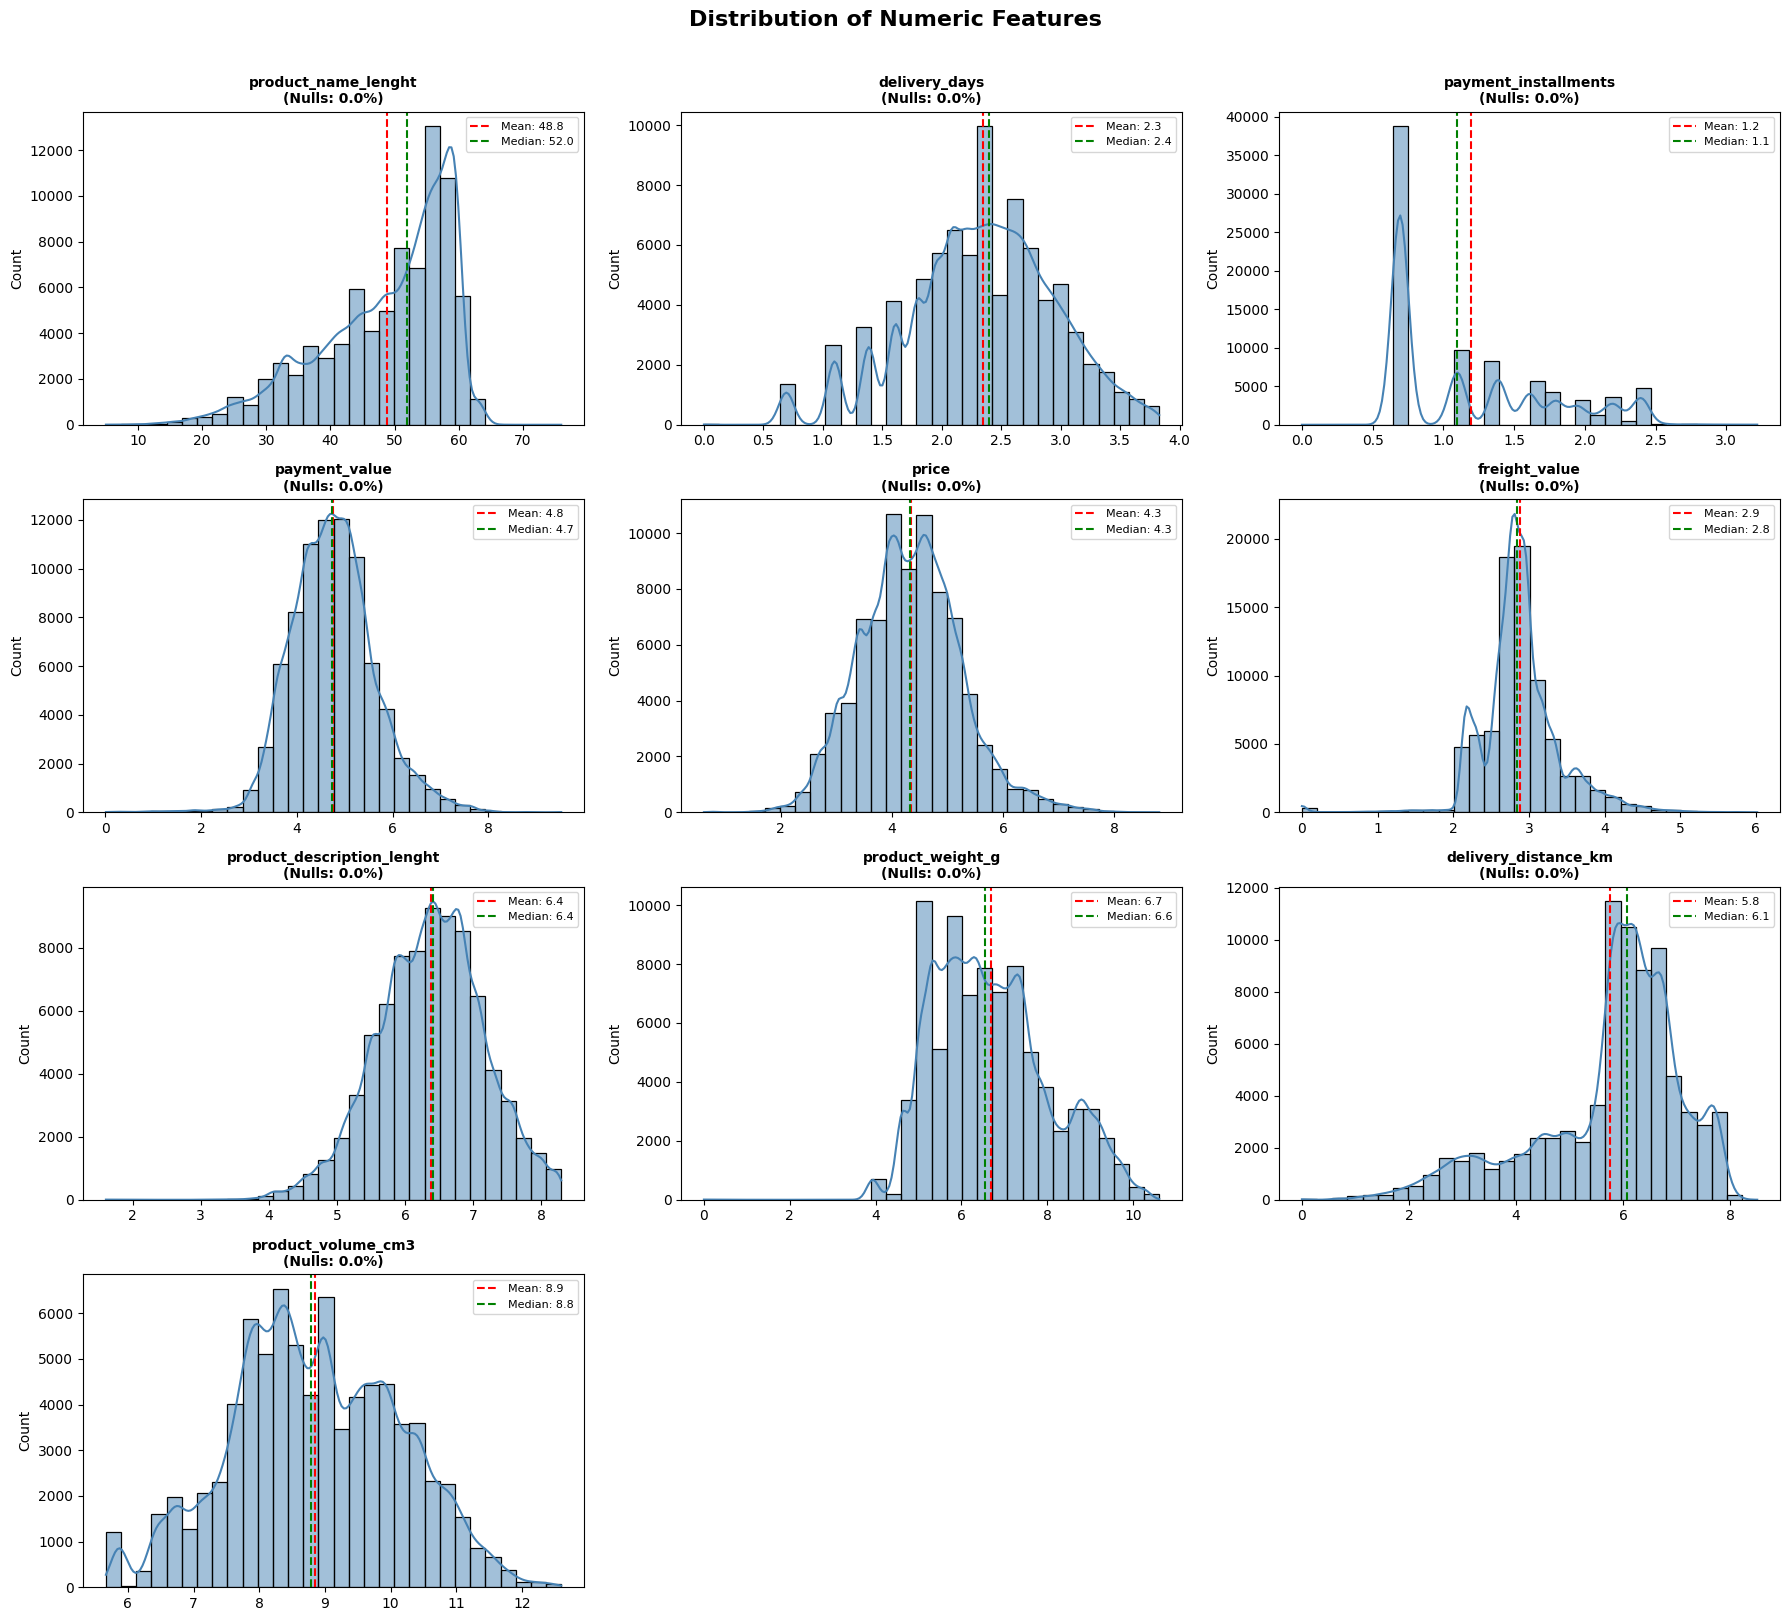

In [37]:
plot_distribution(data)

In [20]:
data.drop(columns=['product_length_cm','product_height_cm','product_width_cm'],inplace=True)

In [21]:

transform_col = ['payment_installments','payment_value','price','freight_value','product_description_lenght',
                 'product_weight_g','delivery_distance_km','product_volume_cm3']

for col in transform_col:
    data[f'{col}_log'] =  np.log1p(data[col])


In [22]:
original_cols_to_drop = [
    'payment_value',
    'price', 
    'freight_value',
    'product_weight_g',
    'product_volume_cm3',
    'delivery_distance_km',
    'product_description_lenght',  # log version exists
    'payment_installments'         # log version exists
]
data.drop(columns=original_cols_to_drop, inplace=True)



In [31]:
rename = {}
[rename.update({f'{x}_log':x}) for x in original_cols_to_drop]


{'payment_value_log': 'payment_value',
 'price_log': 'price',
 'freight_value_log': 'freight_value',
 'product_weight_g_log': 'product_weight_g',
 'product_volume_cm3_log': 'product_volume_cm3',
 'delivery_distance_km_log': 'delivery_distance_km',
 'product_description_lenght_log': 'product_description_lenght',
 'payment_installments_log': 'payment_installments'}

In [34]:
data.rename(columns=rename,inplace=True)

In [36]:
# also transform target column

data['delivery_days'] = np.log1p(data['delivery_days'])

In [50]:


# Drop these - zero correlation with target
data.drop(columns=[
    'product_name_lenght',
    'product_description_lenght'
], inplace=True)

data.drop(columns=['payment_value'], inplace=True)

# product_weight vs product_volume (0.80) → drop one
# weight is more directly related to shipping than volume
data.drop(columns=['product_volume_cm3'], inplace=True)

In [51]:
data

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,customer_unique_id,customer_city,customer_state,product_id,seller_id,shipping_limit_date,product_category_name,product_category_name_english,seller_city,seller_state,delivery_days,payment_installments,price,freight_value,product_weight_g,delivery_distance_km,same_state
0,18668c1a8328478efec728fc614c3b55,6d547f62fd060718fd2a268a4fa2a1fa,delivered,2017-05-04 15:06:03,2017-05-04 15:22:30,2017-05-05 12:00:40,2017-05-23 11:12:49,2017-05-25,credit_card,288bca9dae3585557dfd5dfdf7289600,maua,SP,4fcb3d9a5f4871e8362dfedbdb02b064,8581055ce74af1daba164fdbd55a40de,2017-05-10 15:22:30,automotivo,auto,guarulhos,SP,2.944439,2.197225,4.975353,2.960105,8.691315,3.178054,1
1,e35bd284b205ea082108ae3703c84428,ac8e62b68c0a8fd4d4eb818903300c68,delivered,2017-11-10 13:42:22,2017-11-13 07:50:30,2017-11-14 16:09:51,2017-11-22 14:12:32,2017-12-05,credit_card,9b85684cedccb35b49cbad4fcfe04417,sao paulo,SP,52c80cedd4e90108bf4fa6a206ef6b03,a1043bafd471dff536d0c462352beb48,2017-11-20 07:50:30,ferramentas_jardim,garden_tools,ilicinea,MG,2.564949,1.609438,5.198442,3.859466,8.942592,5.726848,0
2,2fd573eea535b447eea60a9b4aa2603d,f94bd0795b4e39a9250f516c56ee4309,delivered,2018-08-23 17:22:26,2018-08-23 17:35:14,2018-08-24 10:38:00,2018-08-29 15:28:56,2018-09-04,credit_card,7e706e55aec816de5d9b8b8799f5aefd,pocos de caldas,MG,7c88ed4fc8c3ae3a1e08a074cbfc9a88,0bebbb2cea103a4a020c95d43fd7d754,2018-08-27 17:31:06,beleza_saude,health_beauty,sao paulo,SP,1.791759,1.386294,5.388615,3.281287,7.183871,5.262690,0
3,73c8ab38f07dc94389065f7eba4f297a,d5f2b3f597c7ccafbb5cac0bcc3d6024,delivered,2017-12-13 14:21:15,2017-12-15 02:30:41,2017-12-15 18:45:18,2017-12-28 09:05:34,2018-01-08,boleto,31e412b9fb766b6794724ed17a41dfa6,santos,SP,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2017-12-21 02:30:41,ferramentas_jardim,garden_tools,sao jose do rio preto,SP,2.708050,0.693147,4.094345,2.669309,7.346655,6.156979,1
4,26f35d2f228f74c5c9ca3a74c3a88d7c,a04b42b4fd7b36ef879752176cd57557,delivered,2017-06-11 13:38:21,2017-06-11 13:45:15,2017-06-14 16:19:39,2017-06-16 12:05:06,2017-06-26,credit_card,9c66139f2ce43127c1e2d5acbaa2c3b7,campinas,SP,72051794ce762053e191b35035073fd6,6d2f2e3b539480db1e0842b3a4e32e6e,2017-06-15 13:45:15,moveis_decoracao,furniture_decor,guarulhos,SP,1.609438,2.397895,3.400864,2.644755,7.863651,4.356709,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81043,c0c735876359d7431dbd45a8fb0e238b,e2f8991948307e6172c3c55e7d986d9c,delivered,2018-02-23 00:11:32,2018-02-23 20:20:25,2018-02-26 18:57:01,2018-03-08 15:24:09,2018-03-22,credit_card,6b53299bab38efddcd8c561e277c6778,joao pessoa,PB,a5e28e21acf7c99188ad33f688f18837,9f505651f4a6abe901a56cdc21508025,2018-03-01 20:20:25,informatica_acessorios,computers_accessories,sao paulo,SP,2.639057,0.693147,3.526066,3.254243,7.346655,7.707063,0
81044,24940d1052df86d8e24f16e5adf2868e,dde3f6a475d39044e793c94010308629,delivered,2017-05-01 13:31:40,2017-05-01 13:50:16,2017-05-05 15:10:06,2017-05-16 20:21:26,2017-05-30,credit_card,39ab6384afb233546f4559b162bcba4d,piracicaba,SP,f39e720d7174b473f81e8a7103e562fb,b2ba3715d723d245138f291a6fe42594,2017-05-12 13:50:16,papelaria,stationery,sao paulo,SP,2.772589,2.302585,5.169916,2.610805,7.378384,4.976734,1
81045,559d6842e0a3468f1941683ca901b582,cb7e8cd5140cc150773cdc7f06bb737c,delivered,2018-03-12 22:25:18,2018-03-12 23:48:31,2018-03-15 00:03:30,2018-04-24 21:39:33,2018-04-13,credit_card,50985b8d1956bd782be94c09dc9f19a8,lucas do rio verde,MT,1a080577618e7fe4d9ddd8fb2b47a964,7d13fca15225358621be4086e1eb0964,2018-03-18 23:30:28,relogios_presentes,watches_gifts,ribeirao preto,SP,3.761200,1.609438,6.345636,3.284289,6.054439,7.127694,0
81046,1146fb180e28dfbfdbfabd7249026429,7dbbcbff88444c3fcce705d185a3c024,delivered,2018-02-23 11:04:11,2018-02-23 11

In [52]:
print(data.columns.tolist())
print(data.shape)

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'payment_type', 'customer_unique_id', 'customer_city', 'customer_state', 'product_id', 'seller_id', 'shipping_limit_date', 'product_category_name', 'product_category_name_english', 'seller_city', 'seller_state', 'delivery_days', 'payment_installments', 'price', 'freight_value', 'product_weight_g', 'delivery_distance_km', 'same_state']
(80246, 26)


In [53]:
# Check this
print("Total rows:", len(data))
print("Unique orders:", data['order_id'].nunique())

# If these are different → still at item level → need aggregation
# If same → already at order level → ready to encode

Total rows: 80246
Unique orders: 72060


In [54]:
leaky_or_useless = [
    'order_delivered_customer_date',  # used to create target, drop now
    'order_delivered_carrier_date',   # leakage
    'order_estimated_delivery_date',  # leakage - Olist's own prediction
    'order_approved_at',              # leakage
    'shipping_limit_date',            # leakage
    'order_status',                   # already filtered to delivered only
    'customer_id',                    # ID column
    'customer_unique_id',             # ID column
    'product_id',                     # ID column
    'seller_id',                      # ID column
    'customer_city',                  # too granular, state is enough
    'seller_city',                    # too granular, state is enough
    'product_category_name',          # already have english version
    'order_purchase_timestamp',       # already extracted month/year
]


In [55]:
data.drop(columns=leaky_or_useless, inplace=True)
print(data.columns.tolist())

['order_id', 'payment_type', 'customer_state', 'product_category_name_english', 'seller_state', 'delivery_days', 'payment_installments', 'price', 'freight_value', 'product_weight_g', 'delivery_distance_km', 'same_state']


In [56]:
print(data.columns.tolist())
print(data.shape)

['order_id', 'payment_type', 'customer_state', 'product_category_name_english', 'seller_state', 'delivery_days', 'payment_installments', 'price', 'freight_value', 'product_weight_g', 'delivery_distance_km', 'same_state']
(80246, 12)


In [57]:
cat_cols = ['payment_type', 'customer_state', 
            'seller_state', 'product_category_name_english']

for col in cat_cols:
    print(f"{col}: {data[col].nunique()} unique values")
    print(data[col].value_counts().head(3))
    print()

payment_type: 4 unique values
payment_type
credit_card    60604
boleto         16321
voucher         2081
Name: count, dtype: int64

customer_state: 27 unique values
customer_state
SP    34253
RJ    10143
MG     9421
Name: count, dtype: int64

seller_state: 22 unique values
seller_state
SP    57184
PR     6259
MG     6157
Name: count, dtype: int64

product_category_name_english: 71 unique values
product_category_name_english
bed_bath_table    8112
health_beauty     7063
sports_leisure    6278
Name: count, dtype: int64



In [58]:
data = pd.get_dummies(data, columns=['payment_type'], prefix='payment')
# Creates: payment_credit_card, payment_boleto, payment_voucher, payment_debit_card

In [80]:
# Identify one-hot encoded payment columns
payment_cols = [col for col in data.columns if col.startswith('payment_')]

agg_dict = {
    'delivery_days'                      : 'first',  # same for all items in order
    'payment_installments'               : 'max',    # max installments used
    'price'                              : 'sum',    # total order price
    'freight_value'                      : 'sum',    # total freight
    'product_weight_g'                   : 'sum',    # total weight
    'delivery_distance_km'               : 'max',    # furthest seller
    'same_state'                         : 'first',  # same for all items
    'customer_state_encoded'             : 'first',  # same for all items
    'seller_state_encoded'               : 'mean',   # avg across sellers
    'product_category_name_english_encoded': 'mean', # avg across items
    
}

# Add payment one-hot columns
for col in payment_cols:
    agg_dict[col] = 'max'  # 1 if any item used that payment type

df_final = data.groupby('order_id').agg(agg_dict).reset_index()
df_final.drop(columns=['order_id'], inplace=True)

print("Final shape:", df_final.shape)
print("Unique orders:", len(df_final))

Final shape: (72060, 14)
Unique orders: 72060


In [81]:
# Shape should match unique orders
print("Shape:", df_final.shape)          # Should be (72060, ~13)

# No missing values
print("\nMissing values:")
print(df_final.isnull().sum())

# Target distribution
print("\nDelivery days stats:")
print(np.expm1(df_final['delivery_days']).describe())


Shape: (72060, 14)

Missing values:
delivery_days                            0
payment_installments                     0
price                                    0
freight_value                            0
product_weight_g                         0
delivery_distance_km                     0
same_state                               0
customer_state_encoded                   0
seller_state_encoded                     0
product_category_name_english_encoded    0
payment_boleto                           0
payment_credit_card                      0
payment_debit_card                       0
payment_voucher                          0
dtype: int64

Delivery days stats:
count    72060.000000
mean        11.553081
std          7.726250
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max         45.000000
Name: delivery_days, dtype: float64


In [82]:
print(data['delivery_days'].max())   
# If > 5 → not log transformed ❌
# If < 5 → log transformed ✅

3.828641396489095


In [83]:
# Remove 0 delivery days - impossible
df_final = df_final[df_final['delivery_days'] > 0]
print("After removing zeros:", len(df_final))

After removing zeros: 72051


In [84]:
df_final = df_final[df_final['delivery_days'] > 0]
print(df_final['delivery_days'].describe())

count    72051.000000
mean         2.350098
std          0.615689
min          0.693147
25%          1.945910
50%          2.397895
75%          2.772589
max          3.828641
Name: delivery_days, dtype: float64


In [85]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=['delivery_days'])
y = df_final['delivery_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (57640, 13)
X_test:  (14411, 13)
y_train: (57640,)
y_test:  (14411,)


In [86]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Baseline: always predict mean
y_pred_baseline = np.full(len(y_test), y_train.mean())

# Evaluate on actual days (inverse transform)
baseline_mae = mean_absolute_error(
    np.expm1(y_test), 
    np.expm1(y_pred_baseline)
)
print(f"Baseline MAE: {baseline_mae:.2f} days")

Baseline MAE: 5.66 days


In [87]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lr))
lr_r2  = r2_score(np.expm1(y_test), np.expm1(y_pred_lr))

print(f"Linear Regression MAE: {lr_mae:.2f} days")
print(f"Linear Regression R²:  {lr_r2:.3f}")

Linear Regression MAE: 4.56 days
Linear Regression R²:  0.252


In [88]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_rf))
rf_r2  = r2_score(np.expm1(y_test), np.expm1(y_pred_rf))

print(f"Random Forest MAE: {rf_mae:.2f} days")
print(f"Random Forest R²:  {rf_r2:.3f}")

Random Forest MAE: 4.45 days
Random Forest R²:  0.290


In [89]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_xgb))
xgb_r2  = r2_score(np.expm1(y_test), np.expm1(y_pred_xgb))

print(f"XGBoost MAE: {xgb_mae:.2f} days")
print(f"XGBoost R²:  {xgb_r2:.3f}")

XGBoost MAE: 4.41 days
XGBoost R²:  0.291


In [90]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE (days)': [baseline_mae, lr_mae, rf_mae, xgb_mae],
    'R²': [0, lr_r2, rf_r2, xgb_r2]
})

results = results.sort_values('MAE (days)')
print(results)


               Model  MAE (days)        R²
3            XGBoost    4.413509  0.291436
2      Random Forest    4.449309  0.290161
1  Linear Regression    4.562844  0.252440
0           Baseline    5.655917  0.000000


In [91]:
# Correct target encoding ✅
for col in ['customer_state', 'seller_state', 
            'product_category_name_english']:
    
    # Calculate mapping ONLY on train set
    mapping = X_train.groupby(col)['delivery_days'].mean()
    
    # Apply to both train and test
    X_train[f'{col}_encoded'] = X_train[col].map(mapping)
    X_test[f'{col}_encoded']  = X_test[col].map(mapping)

KeyError: 'customer_state'